Data Questions for IMDB

- I want to make the highest grossing movie ever, who should I hire (director, actors, writer)? What genre should it be?
- How has favourite genre changed over time?
- An actor participates in a high grossing movie, how likely is he to get a leading role in the future?
- What is the relation between budget and first weekend gross?
- What is the relation between budget and rating?

data from https://developer.imdb.com/non-commercial-datasets/

In [12]:
%ls -la data

total 3660312
drwxr-xr-x@ 9 m  staff        288 Oct 17 19:18 ./
drwxr-xr-x@ 5 m  staff        160 Oct 17 19:14 ../
-rw-r--r--@ 1 m  staff  291894168 Oct 17 19:18 name.basics.tsv.gz
-rw-r--r--@ 1 m  staff  465056507 Oct 17 19:11 title.akas.tsv.gz
-rw-r--r--@ 1 m  staff  212154380 Oct 17 19:10 title.basics.tsv.gz
-rw-r--r--@ 1 m  staff   78234314 Oct 17 19:09 title.crew.tsv.gz
-rw-r--r--@ 1 m  staff   50959814 Oct 17 19:09 title.episode.tsv.gz
-rw-r--r--@ 1 m  staff  735756366 Oct 17 19:11 title.principals.tsv.gz
-rw-r--r--@ 1 m  staff    8189578 Oct 17 19:09 title.ratings.tsv.gz


In [11]:
import pandas as pd

# Update the path to your TSV file (supports .tsv and compressed .tsv.gz)
tsv_path = 'data/name.basics.tsv.gz'  # e.g., 'title.ratings.tsv.gz'
df = pd.read_csv(tsv_path, sep='\t', na_values=['\\N'], low_memory=False)
df.head()

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899.0,1987.0,"actor,miscellaneous,producer","tt0050419,tt0072308,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924.0,2014.0,"actress,soundtrack,archive_footage","tt0037382,tt0075213,tt0038355,tt0117057"
2,nm0000003,Brigitte Bardot,1934.0,NaN,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949.0,1982.0,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918.0,2007.0,"writer,director,actor","tt0050986,tt0069467,tt0083922,tt0050976"


In [13]:
# Load all IMDB TSV files into dataframes
import pandas as pd
df_name_basics = pd.read_csv('data/name.basics.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
df_title_akas = pd.read_csv('data/title.akas.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
df_title_basics = pd.read_csv('data/title.basics.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
df_title_crew = pd.read_csv('data/title.crew.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
df_title_episode = pd.read_csv('data/title.episode.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
df_title_principals = pd.read_csv('data/title.principals.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
df_title_ratings = pd.read_csv('data/title.ratings.tsv.gz', sep='\t', na_values=['\\N'], low_memory=False)
# Display the first few rows of each dataframe
df_name_basics.head(), df_title_akas.head(), df_title_basics.head(), df_title_crew.head(), df_title_episode.head(), df_title_principals.head(), df_title_ratings.head()

(      nconst      primaryName  birthYear  deathYear  \
 0  nm0000001     Fred Astaire     1899.0     1987.0   
 1  nm0000002    Lauren Bacall     1924.0     2014.0   
 2  nm0000003  Brigitte Bardot     1934.0        NaN   
 3  nm0000004     John Belushi     1949.0     1982.0   
 4  nm0000005   Ingmar Bergman     1918.0     2007.0   
 
                     primaryProfession                           knownForTitles  
 0        actor,miscellaneous,producer  tt0050419,tt0072308,tt0027125,tt0025164  
 1  actress,soundtrack,archive_footage  tt0037382,tt0075213,tt0038355,tt0117057  
 2   actress,music_department,producer  tt0057345,tt0049189,tt0056404,tt0054452  
 3       actor,writer,music_department  tt0072562,tt0077975,tt0080455,tt0078723  
 4               writer,director,actor  tt0050986,tt0069467,tt0083922,tt0050976  ,
      titleId  ordering                      title region language  \
 0  tt0000001         1                 Carmencita    NaN      NaN   
 1  tt0000001         2      

In [18]:
df_name_basics

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899.0,1987.0,"actor,miscellaneous,producer","tt0050419,tt0072308,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924.0,2014.0,"actress,soundtrack,archive_footage","tt0037382,tt0075213,tt0038355,tt0117057"
2,nm0000003,Brigitte Bardot,1934.0,NaN,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949.0,1982.0,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918.0,2007.0,"writer,director,actor","tt0050986,tt0069467,tt0083922,tt0050976"
...,...,...,...,...,...,...
14783556,nm9993714,Romeo del Rosario,NaN,NaN,"animation_department,art_department","tt11657662,tt14069590,tt2455546"
14783557,nm9993716,Essias Loberg,NaN,NaN,NaN,NaN
14783558,nm9993717,Harikrishnan Rajan,NaN,NaN,cinematographer,tt8736744
14783559,nm9993718,Aayush Nair,NaN,NaN,cinematographer,tt8736744


In [19]:
df_title_akas

,titleId,ordering,title,region,language,types,attributes,isOriginalTitle
0,tt0000001,1,Carmencita,NaN,NaN,original,NaN,1
1,tt0000001,2,Carmencita,DE,NaN,NaN,literal title,0
2,tt0000001,3,Carmencita,US,NaN,imdbDisplay,NaN,0
3,tt0000001,4,Carmencita - spanyol tánc,HU,NaN,imdbDisplay,NaN,0
4,tt0000001,5,Καρμενσίτα,GR,NaN,imdbDisplay,NaN,0
...,...,...,...,...,...,...,...,...
53339500,tt9916852,7,エピソード #3.20,JP,ja,NaN,NaN,0
53339501,tt9916852,8,Episodio #3.20,ES,es,NaN,NaN,0
53339502,tt9916856,1,The Wind,NaN,NaN,original,NaN,1
53339503,tt9916856,2,The Wind,DE,NaN,imdbDisplay,NaN,0


In [20]:
df_title_basics

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,decade
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short",1890.0
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short",1890.0
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance",1890.0
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short",1890.0
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short,1890.0
...,...,...,...,...,...,...,...,...,...,...
11977179,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2009.0,NaN,NaN,Drama,2000.0
11977180,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010.0,NaN,NaN,Drama,2010.0
11977181,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010.0,NaN,NaN,Drama,2010.0
11977182,tt9916856,short,The Wind,The Wind,0,2015.0,NaN,27,Short,2010.0


In [31]:
sorted(df_title_basics['titleType'].dropna().unique())

['movie',
 'short',
 'tvEpisode',
 'tvMiniSeries',
 'tvMovie',
 'tvPilot',
 'tvSeries',
 'tvShort',
 'tvSpecial',
 'video',
 'videoGame']

In [21]:
df_title_crew

,tconst,directors,writers
0,tt0000001,nm0005690,NaN
1,tt0000002,nm0721526,NaN
2,tt0000003,nm0721526,nm0721526
3,tt0000004,nm0721526,NaN
4,tt0000005,nm0005690,NaN
...,...,...,...
11977179,tt9916848,nm1485677,"nm9187127,nm1485677,nm9826385,nm9299459,nm1628284"
11977180,tt9916850,nm1485677,"nm9187127,nm1485677,nm9826385,nm1628284"
11977181,tt9916852,nm1485677,"nm9187127,nm1485677,nm9826385,nm9299459,nm1628284"
11977182,tt9916856,nm10538645,nm6951431


In [22]:
df_title_episode

,tconst,parentTconst,seasonNumber,episodeNumber
0,tt0031458,tt32857063,NaN,NaN
1,tt0041951,tt0041038,1.0,9.0
2,tt0042816,tt0989125,1.0,17.0
3,tt0042889,tt0989125,NaN,NaN
4,tt0043426,tt0040051,3.0,42.0
...,...,...,...,...
9223439,tt9916846,tt1289683,3.0,18.0
9223440,tt9916848,tt1289683,3.0,17.0
9223441,tt9916850,tt1289683,3.0,19.0
9223442,tt9916852,tt1289683,3.0,20.0


In [23]:
df_title_principals

,tconst,ordering,nconst,category,job,characters
0,tt0000001,1,nm1588970,self,NaN,"[""Self""]"
1,tt0000001,2,nm0005690,director,NaN,NaN
2,tt0000001,3,nm0005690,producer,producer,NaN
3,tt0000001,4,nm0374658,cinematographer,director of photography,NaN
4,tt0000002,1,nm0721526,director,NaN,NaN
...,...,...,...,...,...,...
95276234,tt9916880,17,nm0996406,director,principal director,NaN
95276235,tt9916880,18,nm1482639,writer,NaN,NaN
95276236,tt9916880,19,nm2586970,writer,books,NaN
95276237,tt9916880,20,nm1594058,producer,producer,NaN


In [24]:
df_title_ratings

,tconst,averageRating,numVotes
0,tt0000001,5.7,2181
1,tt0000002,5.5,302
2,tt0000003,6.4,2255
3,tt0000004,5.2,194
4,tt0000005,6.2,2993
...,...,...,...
1627005,tt9916846,5.3,7
1627006,tt9916848,5.2,7
1627007,tt9916850,6.0,7
1627008,tt9916852,5.7,7


In [34]:
movie_basics = df_title_basics[df_title_basics['titleType'] == 'movie']
movie_basics

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,decade
8,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,NaN,45,Romance,1890.0
144,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,NaN,100,"Documentary,News,Sport",1890.0
498,tt0000502,movie,Bohemios,Bohemios,0,1905.0,NaN,100,NaN,1900.0
570,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,NaN,70,"Action,Adventure,Biography",1900.0
587,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,NaN,90,Drama,1900.0
...,...,...,...,...,...,...,...,...,...,...
11977078,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015.0,NaN,57,Documentary,2010.0
11977102,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007.0,NaN,100,Documentary,2000.0
11977114,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013.0,NaN,NaN,Comedy,2010.0
11977124,tt9916730,movie,6 Gunn,6 Gunn,0,2017.0,NaN,116,Drama,2010.0


## 1. Who should I hire (director, actors, writer) and what genre should it be for the highest grossing movie?

In [44]:
from collections import Counter
import itertools

# Find top-rated movies and their crew/genre
movie_basics = df_title_basics[df_title_basics['titleType'] == 'movie']
df_title_ratings_filtered = df_title_ratings[df_title_ratings['numVotes'] > 50000]

top_movies = df_title_ratings_filtered.sort_values('averageRating', ascending=False)
top_movies = top_movies.merge(movie_basics, on='tconst')
top_movies = top_movies.merge(df_title_crew, on='tconst', how='left').head(100)

# Most common genres among top movies
genres = top_movies['genres'].dropna().str.split(',')
genre_counts = Counter(itertools.chain.from_iterable(genres))
print('Top genres:', genre_counts.most_common(10))

# Most frequent directors and writers (split multiple IDs)
def split_and_count(series):
    all_items = series.dropna().astype(str).str.split(',')
    flat = list(itertools.chain.from_iterable(all_items))
    return Counter(flat)
director_counts = split_and_count(top_movies['directors'])
writer_counts = split_and_count(top_movies['writers'])
# Map nconst to names for directors and writers
name_map = df_name_basics.set_index('nconst')['primaryName'].to_dict()
top_director_names = [(name_map.get(nconst, nconst), count) for nconst, count in director_counts.most_common(10)]
top_writer_names = [(name_map.get(nconst, nconst), count) for nconst, count in writer_counts.most_common(10)]
print('Top directors:', top_director_names)
print('Top writers:', top_writer_names)

# Most frequent actors in top movies
top_principals = df_title_principals[df_title_principals['tconst'].isin(top_movies['tconst'])]
top_actors = top_principals[top_principals['category']=='actor']['nconst']
actor_counts = split_and_count(top_actors)
# Map nconst to names
actor_names = df_name_basics.set_index('nconst')['primaryName'].to_dict()
top_actor_names = [(actor_names.get(nconst, nconst), count) for nconst, count in actor_counts.most_common(10)]
print('Top actors:', top_actor_names)

Top genres: [('Drama', 78), ('Adventure', 27), ('Crime', 21), ('Action', 20), ('Mystery', 12), ('Biography', 11), ('Comedy', 11), ('Animation', 11), ('War', 11), ('Sci-Fi', 10)]
Top directors: [('Christopher Nolan', 6), ('Francis Ford Coppola', 3), ('Peter Jackson', 3), ('Steven Spielberg', 3), ('Quentin Tarantino', 3), ('Charles Chaplin', 3), ('Stanley Kubrick', 3), ('Frank Darabont', 2), ('Sergio Leone', 2), ('Robert Zemeckis', 2)]
Top writers: [('Christopher Nolan', 6), ('Jonathan Nolan', 5), ('Stephen King', 3), ('Francis Ford Coppola', 3), ('J.R.R. Tolkien', 3), ('Fran Walsh', 3), ('Philippa Boyens', 3), ('Peter Jackson', 3), ('Quentin Tarantino', 3), ('George Lucas', 3)]
Top actors: [('Charles Chaplin', 4), ('Harrison Ford', 4), ('Tom Hanks', 4), ('Morgan Freeman', 4), ('John DiMaggio', 4), ('Sala Baker', 4), ('Aamir Khan', 4), ('Robert Downey Jr.', 4), ('Mark Ruffalo', 4), ('Chris Evans', 4)]


## 2. How has favourite genre changed over time?

/var/folders/lq/pqkwr94x5z3g466bm75m5kr00000gn/T/ipykernel_94832/639545130.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_title_basics['decade'] = (df_title_basics['startYear']//10)*10


<Axes: title={'center': 'Genre Popularity by Decade (Percentual)'}, xlabel='decade', ylabel='Percentage (%)'>

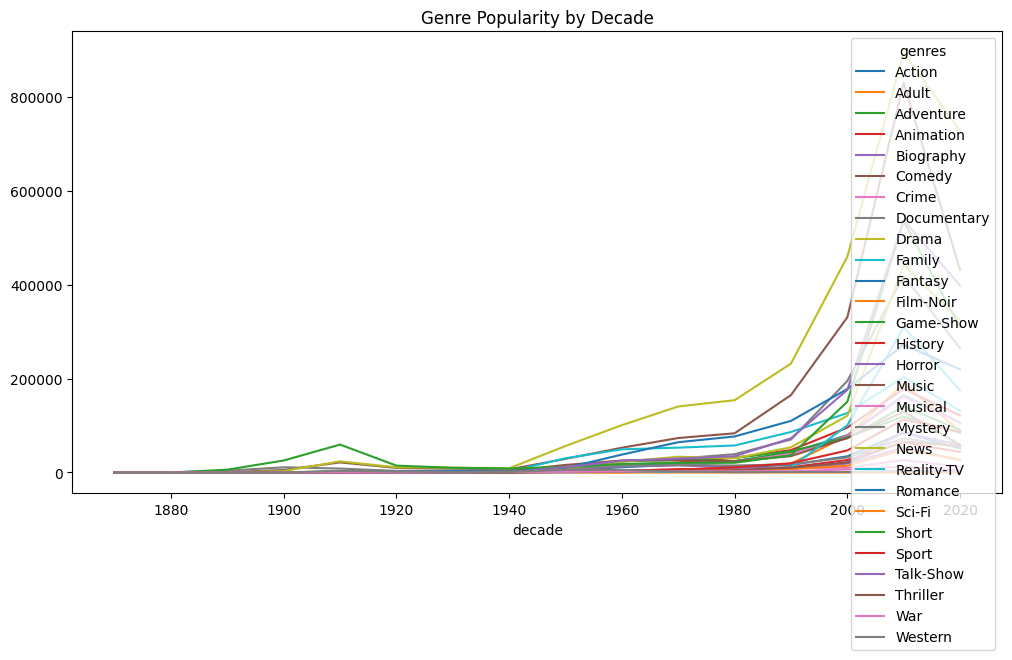

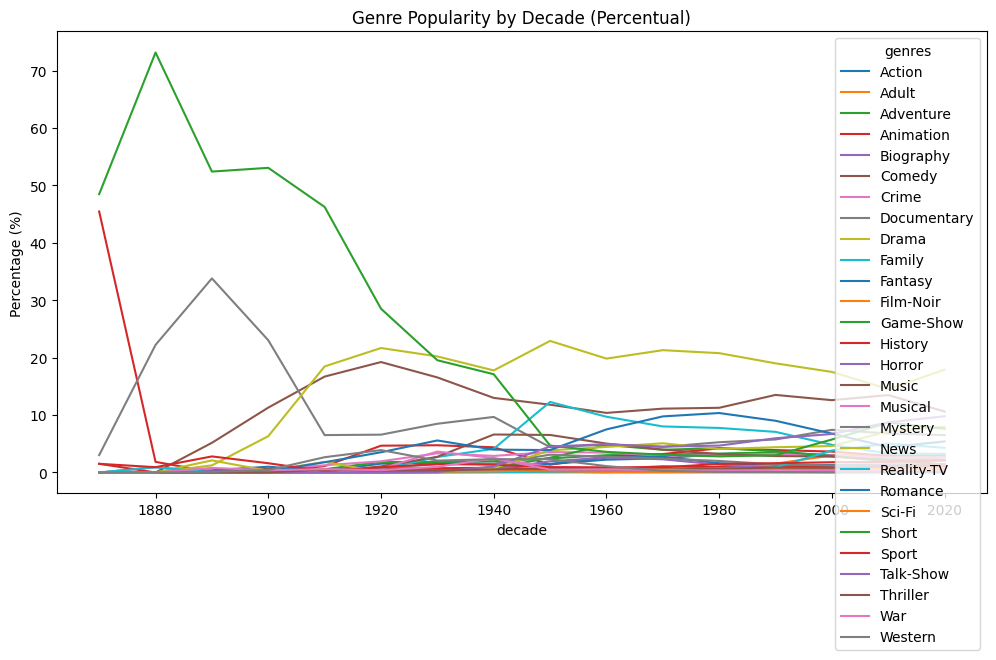

In [42]:
# Analyze genre popularity by decade
df_title_basics['startYear'] = pd.to_numeric(df_title_basics['startYear'], errors='coerce')
# filter out movies after 2025 to avoid incomplete data
df_title_basics = df_title_basics[df_title_basics['startYear'] <= 2025]
df_title_basics['decade'] = (df_title_basics['startYear']//10)*10
genre_decade = df_title_basics.dropna(subset=['genres', 'decade'])
genre_decade = genre_decade.assign(genres=genre_decade['genres'].str.split(','))
genre_exploded = genre_decade.explode('genres')
genre_counts_by_decade = genre_exploded.groupby(['decade', 'genres']).size().unstack(fill_value=0)
genre_counts_by_decade.plot(kind='line', figsize=(12,6), title='Genre Popularity by Decade')

# Percentual chart: each genre as % of total per decade
genre_percent_by_decade = genre_counts_by_decade.div(genre_counts_by_decade.sum(axis=1), axis=0) * 100
genre_percent_by_decade.plot(kind='line', figsize=(12,6), title='Genre Popularity by Decade (Percentual)', ylabel='Percentage (%)')

## 3. If an actor participates in a high grossing movie, how likely are they to get a leading role in the future?

In [28]:
# Find actors in top movies, then check their future leading roles
top_movie_ids = set(top_movies['tconst'])
top_actors = df_title_principals[df_title_principals['tconst'].isin(top_movie_ids) & (df_title_principals['category']=='actor')]
future_roles = df_title_principals[df_title_principals['nconst'].isin(top_actors['nconst']) & (df_title_principals['category']=='actor')]
future_roles = future_roles.merge(df_title_basics[['tconst','startYear']], on='tconst', how='left')
future_roles = future_roles.merge(df_title_ratings[['tconst','averageRating']], on='tconst', how='left')
# Assume 'leading role' if ordering==1
future_leading = future_roles[future_roles['ordering']==1]
prob_leading = len(future_leading) / len(future_roles) if len(future_roles) > 0 else None
print('Probability of getting a future leading role:', prob_leading)

Probability of getting a future leading role: 0.1334629835553226


## 4. What is the relation between budget and first weekend gross?

## 5. What is the relation between budget and rating?